In [57]:
import tensorflow as tf
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
from pylab import rcParams
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dropout,Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns 


In [58]:
x,y=make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

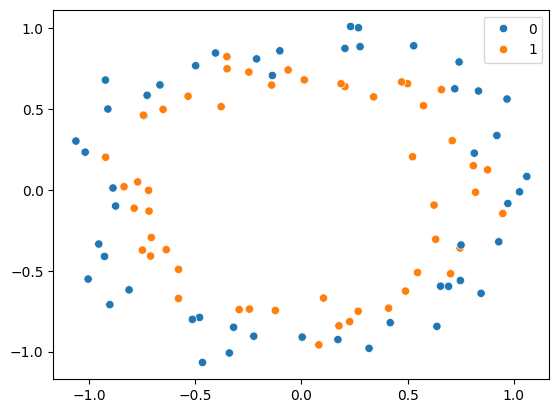

In [59]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [60]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [61]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\KhushiAgarwal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [63]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500,verbose=0)

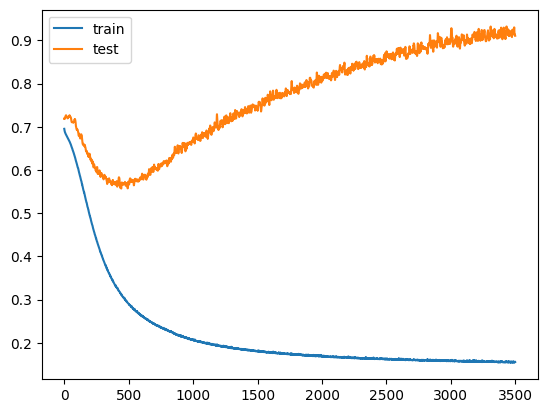

In [64]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


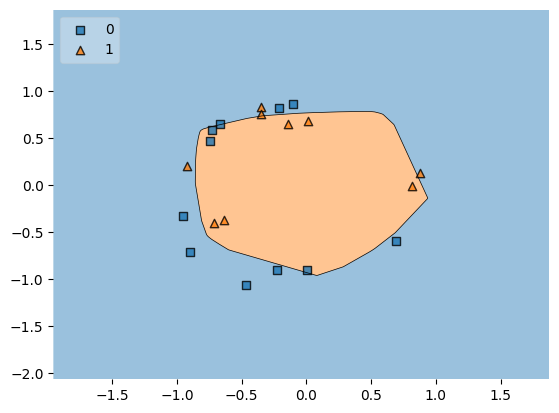

In [65]:
plot_decision_regions(x_test,y_test.ravel(),clf=model,legend=2)
plt.show()

In [66]:
# Early Stopping
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


In [67]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [68]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False)

In [69]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500,callbacks=callback)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - accuracy: 0.5000 - loss: 0.6916 - val_accuracy: 0.4000 - val_loss: 0.7124
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5500 - loss: 0.6890 - val_accuracy: 0.4000 - val_loss: 0.7128
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5375 - loss: 0.6881 - val_accuracy: 0.4000 - val_loss: 0.7137
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5375 - loss: 0.6873 - val_accuracy: 0.4000 - val_loss: 0.7140
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5375 - loss: 0.6867 - val_accuracy: 0.4500 - val_loss: 0.7140
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5375 - loss: 0.6858 - val_accuracy: 0.4500 - val_loss: 0.7145
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5375 - loss: 0.6853 - val_accuracy: 0.4500 - val_loss: 0.7140
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5625 - loss: 0.6844 - val_accuracy: 0.4500 - val_loss: 

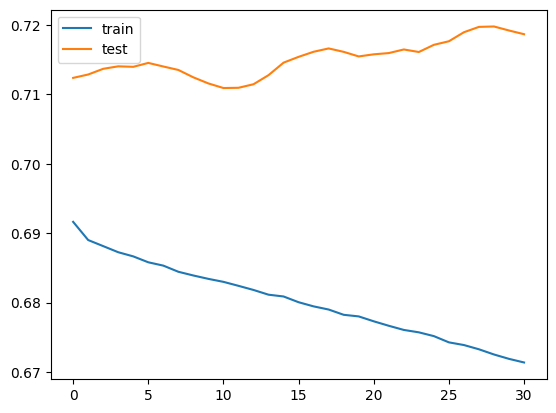

In [70]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


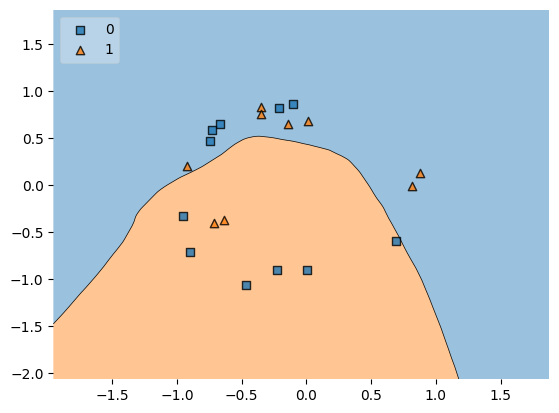

In [71]:
plot_decision_regions(x_test,y_test.ravel(),clf=model,legend=2)
plt.show()